In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_community.chat_models import ChatOllama

c:\Users\Swati\llm_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = ChatOllama(model="llama3", temparature=1.5)

C:\Users\Swati\AppData\Local\Temp\ipykernel_14168\3307222411.py:1: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  model = ChatOllama(model="llama3", temparature=1.5)


In [3]:
# Create state
class ConversationState(TypedDict):
    question: str
    answer: str

In [4]:
def question_answer_function(state: ConversationState) -> ConversationState:
    user_question = state['question']
    # Create Prompt
    prompt = f"Answer the Question : {user_question}\nA:"
    # call model
    response = model.invoke(prompt)
    llm_answer = response.content
    state['answer'] = llm_answer    
    return state

In [6]:
# Create Graph
graph= StateGraph(ConversationState)

# create node
graph.add_node("question_answer", question_answer_function)

# create edges
graph.add_edge(START, "question_answer")
graph.add_edge("question_answer", END)

# compile
workflow = graph.compile()

In [7]:
intial_state = {'question': 'How far is moon from the earth?'}
final_state = workflow.invoke(intial_state)
print(final_state)

{'question': 'How far is moon from the earth?', 'answer': 'The average distance from the Earth to the Moon is about 384,400 kilometers (238,900 miles). This is called the "lunar distance" or "lunar mean distance." However, the Moon\'s orbit is not a perfect circle and its distance from Earth varies slightly due to the elliptical shape of its orbit. At its closest point, known as perigee, the Moon is about 356,400 kilometers (221,500 miles) away, and at its farthest point, or apogee, it\'s around 405,500 kilometers (252,000 miles) away.'}


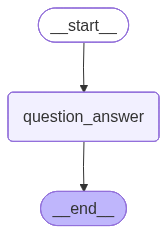

In [8]:
workflow